<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Детекция объектов</b></h3>

В этом домашнем задании мы продолжим работу над детектором из семинара, поэтому при необходимости можете заимствовать оттуда любой код.

Домашнее задание можно разделить на следующие части:

* Переделываем модель [4]
  * Backbone[1],
  * Neck [2],
  * Head [1]
* Label assignment [3]:
  * TAL [3]
* Лоссы [1]:
  * CIoU loss [1]
* Кто больше? [5]
  * 0.05 mAP [1]
  * 0.1 mAP  [2]
  * 0.2 mAP [5]

**Максимальный балл:** 10 баллов. (+3 балла бонус).

In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import box_iou, nms, distance_box_iou_loss
from torchvision import transforms
from torchvision.models.detection.anchor_utils import AnchorGenerator
import numpy as np
import pandas as pd
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import io
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
from torchmetrics.detection import MeanAveragePrecision
from functools import partial

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Константы

NUM_CLASSES = 4
IMG_SIZE = 320
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

# Id класса в наименование класса
class_to_name = {1: 'enemy', 2: 'enemy-head', 3: 'friendly', 4: 'friendly-head'}

### Загрузка данных

Мы продолжаем работу с датасетом из семинара - Halo infinite ([сслыка](https://universe.roboflow.com/graham-doerksen/halo-infinite-angel-aim)). Загрузка данных и создание датасета полностью скопированы из семинара.

Сначала загружаем данные

In [4]:
splits = {'train': 'data/train-00000-of-00001-0d6632d599c29801.parquet',
          'validation': 'data/validation-00000-of-00001-c6b77a557eeedd52.parquet',
          'test': 'data/test-00000-of-00001-866d29d8989ea915.parquet'}
df_train = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["train"])
df_val = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["validation"])
df_test = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["test"])

Создаем датасет для предобработки данных

In [5]:
class HaloDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        # Колонки с объектами, изображениями и их Id
        self.objects = self.dataframe['objects'].values
        self.images = self.dataframe['image'].values
        self.image_ids = self.dataframe['image_id'].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_bytes = self.images[idx]['bytes']
        image = Image.open(io.BytesIO(image_bytes)).convert('RGB')
        image = np.array(image).astype(np.float32) / 255.0      # нормализация
        image_id = self.image_ids[idx]

        obj = self.objects[idx]
        boxes_data = obj['bbox']        # coco [x, y, w, h]
        labels_data = obj['category']   # метки классов

        if isinstance(labels_data, (int, float)):
            labels = [labels_data - 1]      # начало с 0
        else:
            labels = [int(l) - 1 for l in labels_data]

        # Приведение ббоксов к единому формату
        boxes = []
        if isinstance(boxes_data, np.ndarray):
            if boxes_data.dtype == object:
                for box in boxes_data:
                    boxes.append([float(x) for x in box])
            elif boxes_data.ndim == 1:
                boxes.append([float(x) for x in boxes_data])
            else:
                for box in boxes_data:
                    boxes.append([float(x) for x in box])

        boxes = np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 4), dtype=np.float32)

        # xywh -> xyxy
        if len(boxes) > 0:
            boxes_xyxy = boxes.copy()
            boxes_xyxy[:, 2] = boxes[:, 0] + boxes[:, 2]
            boxes_xyxy[:, 3] = boxes[:, 1] + boxes[:, 3]
            boxes = boxes_xyxy

        # Применение аугментаций
        if self.transform is not None:
            transformed = self.transform(
                image=image,
                bboxes=boxes.tolist() if len(boxes) > 0 else [],
                labels=labels
            )
            image = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['labels']
            
            # if len(boxes) != len(labels):
            #     min_len = min(len(boxes), len(labels))
            #     boxes = boxes[:min_len]
            #     labels = labels[:min_len]
            
            boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.empty((0, 4), dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64) if labels else torch.empty((0,), dtype=torch.int64)
        else:
            image = transforms.ToTensor()(image)
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        return image, {'image_id': image_id, 'boxes': boxes, 'labels': labels}

In [6]:
def collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    targets = [item[1] for item in batch]

    # [B, C, H, W], targets
    return images, targets

Чтобы модель не переобучалась, можно добавить больше аугментаций, весь список можно посмотреть тут [[ссылка](https://explore.albumentations.ai/)].

Какие можно использовать аугментации?
* Добавить зум `RandomResizedCrop`,
* Сделать цветовые аугментации типа `RandomBrightnessContrast` и/или `HueSaturationValue`,
* Добавить шум `GaussNoise`,
* Вырезать случайные части изображения `CoarseDropout`,
* И любые другие!

Аугментации можно комбинировать посредствам `A.OneOf`, `A.SomeOf` или `A.RandomOrder`.

Хоть аугментации ограничиваются только вашей фантазией, перед обучением советуем посмотреть на результат преобразований и убедиться, что изображение ещё поддается детекции:)

In [7]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),       # ресайз к единому размеру
    A.HorizontalFlip(p=0.5),            # отражение по горизонтали
    A.RandomBrightnessContrast(p=0.3),  # изменение яркости и контраста
    A.HueSaturationValue(p=0.2),        # изменение оттенка
    A.GaussNoise(p=0.2),                # добавление шумности
    A.Normalize(mean=MEAN, std=STD),    # нормализация с параметрами MEAN STD
    ToTensorV2(),                       # в torch тензор [C, H, W] со значениями в [0, 1]
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))  # к формату 'pascal_voc' для совместимости

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),       # ресайз к единому размеру
    A.Normalize(mean=MEAN, std=STD),    # нормализация с параметрами MEAN STD
    ToTensorV2(),                       # в torch тензор [C, H, W] со значениями в [0, 1]
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))  # к формату 'pascal_voc' для совместимости

Не забываем инициализировать наш датасет

In [8]:
train_dataset = HaloDataset(df_train, transform=train_transform)
val_dataset = HaloDataset(df_val, transform=test_transform)
test_dataset = HaloDataset(df_test, transform=test_transform)

## Переделываем модель [4 балла]

В семинаре мы реализовали самый базовый детектор, а сейчас настало время его улучшать. 

### Backbone [1 балл]

Хорошей практикой считается размораживать несколько последних слоев в backbone, это позволяет немного улучить качество модели. Давайте улушчим класс Backbone из лекции, добавив ему возможность разморозки __k__ последних слоев или блоков (на ваш выбор).

Используем предобученную модель efficientnet_b0 и разморозим несколько последних слоев

In [9]:
class Backbone(nn.Module):
    def __init__(self, model_name='efficientnet_b0', out_indices=(-3, -2, -1), unfreeze_last=3, dropout=0.2):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, 
            pretrained=True, 
            features_only=True, 
            out_indices=out_indices
        )
        
        for p in self.backbone.parameters():
            p.requires_grad = False
        

        if unfreeze_last is not None and unfreeze_last > 0:
            self._unfreeze_blocks(unfreeze_last)
        
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
    
    def _unfreeze_blocks(self, num_blocks):
        """
        Разморозка последних блоков
        """
        total_blocks = 0
        for name, _ in self.backbone.named_parameters():
            if 'blocks.' in name:
                # Извлечение индексов блока из имени параметра
                block_idx = int(name.split('blocks.')[1].split('.')[0])
                total_blocks = max(total_blocks, block_idx + 1)
        
        start_block = max(0, total_blocks - num_blocks)
        
        for name, param in self.backbone.named_parameters():
            if 'blocks.' in name:
                block_idx = int(name.split('blocks.')[1].split('.')[0])
                if block_idx >= start_block:
                    param.requires_grad = True
            # Разморозка головы
            elif any(x in name for x in ['conv_head', 'bn2', 'classifier', 'global_pool']):
                param.requires_grad = True

    def forward(self, x):
        features = self.backbone(x)
        return [self.dropout(f) for f in features]  # уменьшаем переобучение с помощью dropout

### NECK [2 балла]

Следующее улучшение коснется шеи. Предлагаем реализовать знакомую из лекции архитектуру FPN.

#### Feature Pyramid Network

<center><img src="https://user-images.githubusercontent.com/57972646/69858594-b14a6c00-12d5-11ea-8c3e-3c17063110d3.png"/></center>


* [Feature Pyramid Networks for Object Detection](https://arxiv.org/abs/1612.03144)

Она состоит из top-down пути, в котором происходит 2 вещи:
1. Увеличивается пространственная размерность фичей,
2. С помощью скипконнекшеннов, добавляются фичи из backbone модели.

Для увеличения пространственной размерности используется __nearest neighbor upsampling__, а фичи из шеи и бекбоуна суммируются.

__TIPS__:
* Можете использовать базовые классы из лекции,
* Воспользуйтесь AnchorGenerator-ом, чтобы создавать якоря сразу для нескольких выходов,
* Не забудьте использовать nn.ModuleList, если захотите сделать динамическое количество голов у модели,
* Также, можно добавить доп конволюцию (3х3 с паддингом) у каждого выхода шеи.

В качестве Шеи использую реализацию Feature Pyramid Network (FPN),  
Также использую CSPBlock (Cross-Stage Partial) для улучшения градиентного потока.

In [10]:
class CSPBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        hidden = channels // 2
        

        # Ветка 1: через bottleneck
        self.conv1 = nn.Sequential(
            nn.Conv2d(channels, hidden, 1),
            nn.BatchNorm2d(hidden),
            nn.SiLU()
        )

        # Ветка 2: напрямую
        self.conv2 = nn.Sequential(
            nn.Conv2d(channels, hidden, 1),
            nn.BatchNorm2d(hidden),
            nn.SiLU()
        )

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.SiLU(),
            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.SiLU(),
        )

        # Объединение веток
        self.merge = nn.Sequential(
            nn.Conv2d(hidden * 2, channels, 1),
            nn.BatchNorm2d(channels),
            nn.SiLU()
        )
        
    def forward(self, x):
        return self.merge(torch.cat([self.bottleneck(self.conv1(x)), self.conv2(x)], dim=1))

In [11]:
class Neck(nn.Module):
    def __init__(self, in_channels_list=(24, 40, 112), out_channels=128):
        super().__init__()
        self.lateral = nn.ModuleList([
            nn.Conv2d(in_ch, out_channels, 1) for in_ch in in_channels_list
        ])
        # CSP блоки
        self.output = nn.ModuleList([
            CSPBlock(out_channels) for _ in in_channels_list
        ])

    def forward(self, features):
        # От backbone
        c3, c4, c5 = features
        
        p5 = self.lateral[2](c5)
        p4 = self.lateral[1](c4) + F.interpolate(p5, size=c4.shape[-2:], mode='nearest')
        p3 = self.lateral[0](c3) + F.interpolate(p4, size=c3.shape[-2:], mode='nearest')
        
        return [self.output[i](p) for i, p in enumerate([p3, p4, p5])]      # CSP блоки к каждому уровню

### Head [1 балл]

В качестве шеи можно выбрать __один из двух__ вариантов:

#### 1. Decoupled Head

Реализовать Decoupled Head из [YOLOX](https://arxiv.org/abs/2107.08430).
<center><img src="https://i.ibb.co/BVtBR2R3/Decoupled-head.jpg"/></center>

**TIP**: Возьмите за основу голову из семинара, тк она сильно похожа на Decoupled Head.

Изменять количество параметров у шей на разных уровнях не обязательно.

#### 2. Confidence score free head

Нужно взять за основу голову из семинара и полностью убрать предсказание confidence score. Чтобы модель предсказывала только 2 группы: ббоксы и классы.

Есть следующие способы удаления confidence score:
* Добавление нового класса ФОН. Обычно его обозначают нулевым классом.
* Присваивание ббоксам БЕЗ объекта вектор из нулей в качестве таргета.

Выберете тот, который вам больше нравится и будте внимательны при расчете лосса! 

**Важно!** Удаление confidence score повлияет на следующие методы из семинара:
* target_assign
* ComputeLoss
* _filter_predictions

Использую разделенную голову: ветка классификации и ветка регрессии.  
Также будут использованы  блоки CSP.

In [ ]:
class Head(nn.Module):
    def __init__(self, in_channels, num_anchors, num_classes, hidden_channels=128):
        super().__init__()
        self.num_classes = num_classes
        self.num_anchors = num_anchors
        
        self.stem = nn.Conv2d(in_channels, hidden_channels, kernel_size=1)

        # Ветка классификации
        self.cls_branch = nn.Sequential(
            CSPBlock(hidden_channels),
            CSPBlock(hidden_channels),
            nn.Conv2d(hidden_channels, num_anchors * num_classes, kernel_size=1)    # num_anchors * num_classes каналов 
        )

        # Ветка регрессии
        self.reg_branch = nn.Sequential(
            CSPBlock(hidden_channels),
            CSPBlock(hidden_channels),
            nn.Conv2d(hidden_channels, num_anchors * 5, kernel_size=1)      # num_anchors * 5 каналов 
        )
        
        # Инициализация изначального смещения bias
        nn.init.constant_(self.reg_branch[-1].bias, -4.5)
        nn.init.constant_(self.cls_branch[-1].bias, -4.5)

    def forward(self, x):
        x = self.stem(x)
        cls_logits = self.cls_branch(x)
        reg_out = self.reg_branch(x)
        
        bbox_preds = reg_out[:, :self.num_anchors * 4, :, :]
        obj_logits = reg_out[:, self.num_anchors * 4:, :, :]
        
        return cls_logits, bbox_preds, obj_logits

Теперь можно снова реализовать класс детектора с учетом всех частей выше!

In [ ]:
class Detector(nn.Module):
    def __init__(self, backbone_name='efficientnet_b0', neck_channels=128, num_classes=4,
                 anchor_sizes=((24, 40, 56), (64, 96, 128), (160, 224, 288)), 
                 anchor_ratios=((0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0)), 
                 input_size=(320, 320), unfreeze_last=3, dropout=0.2):
        super().__init__()
        self.num_classes = num_classes
        self.input_size = input_size
        
        self.backbone = Backbone(
            model_name=backbone_name, 
            out_indices=(-3, -2, -1),
            unfreeze_last=unfreeze_last,
            dropout=dropout
        )
        
        backbone_channels = self.backbone.backbone.feature_info.channels()
        reductions = self.backbone.backbone.feature_info.reduction()
        self.strides = [int(r) for r in reductions]
        self.num_levels = len(self.strides)
        
        self.neck = Neck(
            in_channels_list=backbone_channels,
            out_channels=neck_channels
        )
        
        # Количество якорей
        self.num_anchors_per_loc = len(anchor_sizes[0]) * len(anchor_ratios[0])
        
        self.head = Head(
            in_channels=neck_channels,
            num_anchors=self.num_anchors_per_loc,
            num_classes=num_classes,
            hidden_channels=neck_channels
        )
        
        # Генератор якорей
        self.anchor_generator = AnchorGenerator(
            sizes=tuple(tuple(s) for s in anchor_sizes),
            aspect_ratios=tuple(tuple(r) for r in anchor_ratios),
        )
        # Кеш для якорей
        self._anchor_cache = {}

    def _get_anchors(self, feat_shapes, device):
        """
        Генерация якоря или получение якоря из кеша
        """
        key = (tuple((int(h), int(w)) for h, w in feat_shapes), str(device))
        if key in self._anchor_cache:
            return self._anchor_cache[key]

        grid_sizes = [[int(h), int(w)] for h, w in feat_shapes]
        strides = [[s, s] for s in self.strides]
        per_level = self.anchor_generator.grid_anchors(grid_sizes, strides=strides)
        per_level = [a.to(device) for a in per_level]

        flat = torch.cat(per_level, dim=0)
        # Центры и размеры якорей
        centers = (flat[:, :2] + flat[:, 2:]) / 2   # (x1+x2)/2, (y1+y2)/2
        sizes = flat[:, 2:] - flat[:, :2]           # w, h
        per_anchor_stride = torch.cat([
            torch.full((a.shape[0],), float(s), device=device)
            for a, s in zip(per_level, self.strides)
        ], dim=0)

        cached = (flat, centers, sizes, per_anchor_stride)
        self._anchor_cache[key] = cached
        return cached

    def forward(self, x):
        features = self.backbone(x)
        pyramid = self.neck(features)

        N = x.shape[0]
        bbox_offsets_levels = []
        obj_logits_levels = []
        cls_logits_levels = []
        feat_shapes = []
        
        for feat in pyramid:
            H, W = feat.shape[-2:]
            feat_shapes.append((H, W))
            
            cls_logits, bbox_preds, obj_logits = self.head(feat)
            
            # Из [N, C, H, W] в [N, H*W*num_anchors, ...]
            cls_logits = cls_logits.permute(0, 2, 3, 1).reshape(N, -1, self.num_classes)
            bbox_offsets = bbox_preds.permute(0, 2, 3, 1).reshape(N, -1, 4)
            obj_logits = obj_logits.permute(0, 2, 3, 1).reshape(N, -1)
            
            # Объединение предсказаний со всех уровней
            bbox_offsets_levels.append(bbox_offsets)
            obj_logits_levels.append(obj_logits)
            cls_logits_levels.append(cls_logits)

        bbox_offsets = torch.cat(bbox_offsets_levels, dim=1)
        obj_logits = torch.cat(obj_logits_levels, dim=1)
        cls_logits = torch.cat(cls_logits_levels, dim=1)
        
        anchors, centers, sizes, strides_per_anchor = self._get_anchors(feat_shapes, x.device)
        self.anchors = anchors
        self.anchor_centers = centers
        self.anchor_sizes = sizes
        self.anchor_strides = strides_per_anchor

        if self.training:
            return bbox_offsets, obj_logits, cls_logits

        bboxes = self.decode_bboxes(bbox_offsets)
        return bboxes, torch.sigmoid(obj_logits), torch.sigmoid(cls_logits)

    def decode_bboxes(self, offsets):
        """
        Декодирование смещений в координаты
        """
        tx, ty, tw, th = offsets[..., 0], offsets[..., 1], offsets[..., 2], offsets[..., 3]

        anc_cx = self.anchor_centers[:, 0]
        anc_cy = self.anchor_centers[:, 1]
        anc_w = self.anchor_sizes[:, 0]
        anc_h = self.anchor_sizes[:, 1]
        stride = self.anchor_strides

        # Декодирование центра
        cx = anc_cx + (torch.sigmoid(tx) * 2 - 0.5) * stride
        cy = anc_cy + (torch.sigmoid(ty) * 2 - 0.5) * stride
        # Декодирование размеров
        w = (torch.sigmoid(tw) * 2) ** 2 * anc_w
        h = (torch.sigmoid(th) * 2) ** 2 * anc_h

        # В формат xyxy и ограничение размера изображения
        x1 = torch.clamp(cx - w / 2, 0, self.input_size[0])
        y1 = torch.clamp(cy - h / 2, 0, self.input_size[1])
        x2 = torch.clamp(cx + w / 2, 0, self.input_size[0])
        y2 = torch.clamp(cy + h / 2, 0, self.input_size[1])

        return torch.stack([x1, y1, x2, y2], dim=-1)

## Label assignment [3 балла]
В этой секции предлагается заменить функцию `assign_target` на более современный алгоритм который называется Task alignment learning.

Он описан в статье [TOOD](https://arxiv.org/abs/2108.07755) в секции 3.2. Для удобства вот его основные шаги:

1. Посчитать значение метрики для каждого предсказанного ббокса:
    
$$t = s^\alpha * u^\beta$$
    
где,
* $s$ — classification score, или вероятность принадлежности предсказанного ббокса к классу реального ббокса (**GT**);
* $u$ — IoU между предсказанным и реальным ббоксами;
* $\alpha,\ \beta$ — нормализационные константы, обычно $\alpha = 6.0, \ \beta = 1.0$.
    
2. Отфильтровать предсказания на основе **GT**.

    Для якорных детекторов, обычно, выбираются только те предсказания, центры якорей которых находятся внутри GT.
4. Для каждого **GT** выбрать несколько (обычно 5 или 13) самых подходящих предсказаний.
5. Если предсказание рассматривается в качестве подходящего для нескольких **GT** — выбрать **GT** с наибольшим пересечением по IoU.


**BAЖНО**: если будете использовать Runner из лекции, не забудьте поменять параметры  в `self.assign_target_method` в методе `_run_train_epoch`.

In [ ]:
def TAL_assigner(
    anchors,
    pred_boxes,
    pred_cls_logits,
    gt_boxes,
    gt_labels,
    num_classes,
    alpha=6.0,
    beta=1.0,
    topk=10,
    iou_only=False
):
    device = anchors.device
    A = anchors.shape[0]    # общее количество якорей
    M = gt_boxes.shape[0]   # количество GT объектов на изображении

    # Инициализация целевых значений
    target_gt_boxes = torch.zeros((A, 4), device=device)
    target_objectness = torch.zeros(A, device=device)
    target_cls = torch.zeros((A, num_classes), device=device)
    
    if M == 0:
        return target_gt_boxes, target_objectness, target_cls

    anchor_ious = box_iou(anchors, gt_boxes)

    # Вычисление IoU между якорями и GT
    if iou_only:
        alignment = anchor_ious.clamp(min=0)
    else:
        pred_ious = box_iou(pred_boxes, gt_boxes).clamp(min=0)
        cls_probs = torch.sigmoid(pred_cls_logits)
        alignment = torch.zeros_like(pred_ious)
        for gt_idx in range(M):
            cls_id = int(gt_labels[gt_idx])
            s = cls_probs[:, cls_id]
            u = pred_ious[:, gt_idx]
            alignment[:, gt_idx] = (s ** alpha) * (u ** beta)

    anchor_centers = (anchors[:, :2] + anchors[:, 2:]) / 2    # центры якорей

    assigned_gt = torch.full((A,), -1, dtype=torch.long, device=device)
    assigned_score = torch.full((A,), -1.0, device=device)

    for gt_idx in range(M):
        gt_box = gt_boxes[gt_idx]
        inside_mask = (
            (anchor_centers[:, 0] >= gt_box[0]) &
            (anchor_centers[:, 0] <= gt_box[2]) &
            (anchor_centers[:, 1] >= gt_box[1]) &
            (anchor_centers[:, 1] <= gt_box[3])
        )
        valid_idx = inside_mask.nonzero(as_tuple=True)[0]
        
        # Если ни один центр не попал внутрь GT, то выбираем якорь с максимальным IoU
        if len(valid_idx) == 0:
            ious_for_gt = anchor_ious[:, gt_idx]
            if ious_for_gt.max() > 0:
                k_fb = min(topk, A)
                _, valid_idx = torch.topk(ious_for_gt, k_fb)
            else:
                # Если IoU равен 0, то выбираем ближайшие якори
                gt_cx = (gt_box[0] + gt_box[2]) / 2
                gt_cy = (gt_box[1] + gt_box[3]) / 2
                dist = (anchor_centers[:, 0] - gt_cx) ** 2 + (anchor_centers[:, 1] - gt_cy) ** 2
                k_fb = min(topk, A)
                _, valid_idx = torch.topk(-dist, k_fb)

        # top-k лучших по метрике alignment
        k = min(topk, len(valid_idx))
        _, topk_idx = torch.topk(alignment[valid_idx, gt_idx], k)
        selected = valid_idx[topk_idx]

        # Выбор лучшего якоря по метрике alignment
        cur_scores = alignment[selected, gt_idx]
        better = cur_scores > assigned_score[selected]
        winners = selected[better]
        assigned_score[winners] = cur_scores[better]
        assigned_gt[winners] = gt_idx

    pos_mask = assigned_gt >= 0
    pos_indices = pos_mask.nonzero(as_tuple=True)[0]

    if len(pos_indices) > 0:
        gt_for_pos = assigned_gt[pos_indices]
        target_gt_boxes[pos_indices] = gt_boxes[gt_for_pos]
        target_objectness[pos_indices] = 1.0
        target_cls[pos_indices, gt_labels[gt_for_pos]] = 1.0

    return target_gt_boxes, target_objectness, target_cls

### DIoU [1]

Вместо SmoothL1, который используется в семинаре, реализуем лосс, основанный на пересечении ббоксов. В качестве тренировки давайте напишем Distance Intersection over Union (DIoU).

<center><img src=https://wikidocs.net/images/page/163613/Free_Fig_5.png></center>

Для его реализации разобъем задачу на части:

**1. Реализуем IoU:**

Пусть даны координаты для предсказанного ($B^p$) и истинного ($B^g$) ббоксов в формате XYXY или VOC PASCAL (левый верхний и правый нижний углы):

$B^p=(x^p_1, y^p_1, x^p_2, y^p_2)$, $B^g=(x^g_1, y^g_1, x^g_2, y^g_2)$, тогда алгоритм расчета будет следующий:

    1. Найдем площади обоих ббоксов:
$$ A^p = (x^p_2 - x^p_1) * (y^p_2 - y^p_1) $$
$$ A^g = (x^g_2 - x^g_1) * (y^g_2 - y^g_1) $$

    2. Посчитаем пересечение между ббоксами:

Тут мы предлагаем вам подумать как в общем виде можно расчитать размеры ббокса, который будет являться пересечением $B^p$ и $B^g$, а затем посчитать его площадь:

$$x^I_1 = \qquad \qquad y^I_1 = $$
$$x^I_2 = \qquad \qquad y^I_2 = $$

В общем виде, площать будет записываться следующим образом:

Если $x^I_2 > x^I_1$ & $y^I_2 > y^I_1$, тогда:

$$I = (x^I_2 - x^I_1) * (y^I_2 - y^I_1)$$

Иначе, $I = 0$.

    3. Считаем объединение ббоксов.

Мы можем посчитать эту площадь как сумму площадей двух ббоксов минус площадь пересечения (тк мы считаем её два раз в сумме площадей):

$$U = A^p + A^g - I$$

    4. Вычисляем IoU.

$$IoU = \frac{I}{U}$$

**2. Посчитаем диагональ выпуклой оболочки:**

Для расчета диагонали, сначала выпишите координаты верхнего левого и правого нижнего углов. Подумайте, чему будут равны эти координаты в общем случае?

$$x^c_1 = \qquad \qquad y^c_1 = $$
$$x^c_2 = \qquad \qquad y^c_2 = $$

Подсказка: Нарисуйте несколько вариантов пересечений предсказания и GT на бумажке, и выпишите координаты для выпуклой оболочки.

Тогда квадрат диагонали можно посчитать по формуле:

$$c^2 = (x^c_2 - x^c_1)^2 + (y^c_2 - y^c_1)^2$$

**3. Рассчитаем расстояние между цетрами ббоксов:**

Сначала находим координаты центров каждого из ббоксов (если ббоксы в формате YOLO, то и считать ничего не нужно), затем считаем Евклидово расстояние между центрами.

$d = $

Собираем все части вместе и считаем лосс по формуле:

$$ DIoU = 1 - IoU + \frac{d^2}{c^2}$$

Помните, что пар ббоксов может быть много! Возвращайте усредненное значение лосса.

In [15]:
def gen_bbox(num_boxes=10):
    min_corner = torch.randint(0, 100, (num_boxes, 2))
    max_corner = torch.randint(50, 150, (num_boxes, 2))

    for i in range(2):
        wrong_order = min_corner[:, i] > max_corner[:, i]
        if wrong_order.any():
            min_corner[wrong_order, i], max_corner[wrong_order, i] = max_corner[wrong_order, i], min_corner[wrong_order, i]
    return torch.cat((min_corner, max_corner), dim=1)        

In [16]:
pred_boxes = gen_bbox(num_boxes=100)
true_boxes = gen_bbox(num_boxes=100)

In [17]:
print(f" DIoU: {distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean").item()}")

 DIoU: 1.019036054611206


In [ ]:
def diou_loss(pred_boxes, gt_boxes, eps=1e-7):
    px1, py1, px2, py2 = pred_boxes[:, 0], pred_boxes[:, 1], pred_boxes[:, 2], pred_boxes[:, 3]
    gx1, gy1, gx2, gy2 = gt_boxes[:, 0], gt_boxes[:, 1], gt_boxes[:, 2], gt_boxes[:, 3]

    # Площади
    pred_area = (px2 - px1).clamp(min=0) * (py2 - py1).clamp(min=0)
    gt_area = (gx2 - gx1).clamp(min=0) * (gy2 - gy1).clamp(min=0)
    
    # Пересечения
    ix1 = torch.maximum(px1, gx1)
    iy1 = torch.maximum(py1, gy1)
    ix2 = torch.minimum(px2, gx2)
    iy2 = torch.minimum(py2, gy2)
    
    inter_w = (ix2 - ix1).clamp(min=0)
    inter_h = (iy2 - iy1).clamp(min=0)
    intersection = inter_w * inter_h
    
    # IoU
    union = pred_area + gt_area - intersection + eps
    iou = intersection / union
    
    # Enclosing box
    cx1 = torch.minimum(px1, gx1)
    cy1 = torch.minimum(py1, gy1)
    cx2 = torch.maximum(px2, gx2)
    cy2 = torch.maximum(py2, gy2)
    c2 = (cx2 - cx1).pow(2) + (cy2 - cy1).pow(2) + eps
    
    # Расстояние между центрами
    pcx = (px1 + px2) / 2
    pcy = (py1 + py2) / 2
    gcx = (gx1 + gx2) / 2
    gcy = (gy1 + gy2) / 2
    d2 = (pcx - gcx).pow(2) + (pcy - gcy).pow(2)
    
    loss = 1 - iou + (d2 / c2)
    return loss.mean()

In [19]:
import numpy as np
pred_boxes = gen_bbox(num_boxes=1000)
true_boxes = gen_bbox(num_boxes=1000)

# проверим что написанный лосс выдает те же результаты что и лосс из торча.
assert np.isclose(diou_loss(pred_boxes, true_boxes), distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean"))

## Кто больше? [5 баллов]

Наконец то мы дошли до самый интересной части. Тут мы раздаем очки за mAP'ы!

Все что вы написали выше вам поможет улучшить качество итогового детектора, настало время узнать насколько сильно :)

За достижения порога по mAP на тестовом наборе вы получаете баллы:
* 0.05 mAP [1]
* 0.1 mAP [2]
* 0.2 mAP [5]


**TIPS**:
1. На семинаре мы специально не унифицировали формат ббоксов между методами, чтобы обратить ваше внимание что за этим нужно следить. Чтобы было проще, сразу унифицируете формат по всему ноутбуку. Советуем использовать формат xyxy, тк IoU и NMS из torch используют именно этот формат. (Не забудьте поменять формат у таргета в `HaloDataset`).

2. Попробуйте перейти к IoU-based лоссу при обучении. То есть обучать не смещения, а сразу предсказывать ббокс.

3. Поэксперементируйте с подходами target assignment'а в процессе обучения. Например, можно на первых итерациях использовать обычный метод, а затем подключить TAL.

4. Добавьте аугментаций!

Можно взять [albumentations](https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/), библиотеку, которую мы использовали всеминаре. Или базовые аугментации из торча [тык](https://pytorch.org/vision/main/transforms.html). Если будете использовать торч, не забудте про ббоксы, transforms из коробки не будет их агументировать.

5. Можете реализовать другую шею, которую мы обсуждали на лекции [Path Aggregation Network](https://arxiv.org/abs/1803.01534) она точно улучшит ваше итоговое качество.

6. Попробуйте добавлять различные блоки из YOLO архитектур в шею вместо единичных конволюционных слоев. (Например, замените конволюции 3х3 на CSP блоки).

7. Попробуйте заменить NMS на другой метод (WeightedNMS, SoftNMS, etc.). Немного ссылок:
    * Статья про SoftNMS [тык](https://arxiv.org/pdf/1704.04503)
    * Статья про WeightedNMS [тык](https://openaccess.thecvf.com/content_ICCV_2017_workshops/papers/w14/Zhou_CAD_Scale_Invariant_ICCV_2017_paper.pdf)
    * Есть их реализация, правда на нумбе [git](https://github.com/ZFTurbo/Weighted-Boxes-Fusion?tab=readme-ov-file)

8. Не бойтесь эксперементировать и удачи!

Также, напишите развернутые ответы на следующие вопросы:

**Questions:**
1. Какой метод label assignment'a помогает лучше обучаться модели? Почему?
2. Какое из сделаных вами улучшений внесло наибольший вклад в качество модели? Как вы думаете, почему это произошло?
3. Какое из сделанных вами улучшений вообще не изменило метрику? Как вы думаете, почему это произошло?

In [ ]:
class ComputeLoss:
    def __init__(self, weight_bbox=2, weight_obj=5, weight_cls=1):
        self.weight_bbox = weight_bbox
        self.weight_obj = weight_obj
        self.weight_cls = weight_cls
        self.obj_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([15.0], device=device))
        self.cls_loss = nn.BCEWithLogitsLoss()

    def __call__(self, predicts, targets):
        pred_boxes_xyxy, pred_obj_logits, pred_cls_logits = predicts
        target_boxes_xyxy, target_obj, target_cls = targets
        
        # Objectness loss для ВСЕХ якорей
        loss_obj = self.obj_loss(pred_obj_logits, target_obj)
        
        # Только для положительных якорей
        pos = target_obj == 1
        if pos.any():
            # DIoU между предсказанными и истинными боксами
            loss_bbox = diou_loss(pred_boxes_xyxy[pos], target_boxes_xyxy[pos])
            # BCE для классификации
            loss_cls = self.cls_loss(pred_cls_logits[pos], target_cls[pos])
        else:
            loss_bbox = torch.tensor(0.0, device=device)
            loss_cls = torch.tensor(0.0, device=device)
        
        return self.weight_bbox * loss_bbox + self.weight_obj * loss_obj + self.weight_cls * loss_cls


In [ ]:
def filter_predictions(predictions, score_threshold=0.05, nms_threshold=0.5, max_boxes_per_cls=50):
    """
    Фильтрация предсказаний
    """
    bboxes_xyxy, obj_scores, cls_probs = predictions
    scores_all = obj_scores[:, :, None] * cls_probs
    num_classes = cls_probs.shape[-1]
    results = []
    
    for boxes, scores in zip(bboxes_xyxy, scores_all):
        preds = {'boxes': [], 'labels': [], 'scores': []}
        for cls in range(num_classes):
            keep = scores[:, cls] > score_threshold
            if not keep.any():
                continue
            
            cls_boxes = boxes[keep]
            cls_scores = scores[keep, cls]
            
            if len(cls_boxes) > max_boxes_per_cls:
                idx = torch.argsort(cls_scores, descending=True)[:max_boxes_per_cls]
                cls_boxes = cls_boxes[idx]
                cls_scores = cls_scores[idx]
            
            # Non-Maximum Suppression
            keep_nms = nms(cls_boxes, cls_scores, nms_threshold)
            for ix in keep_nms:
                preds['boxes'].append(cls_boxes[ix].cpu())
                preds['labels'].append(cls)
                preds['scores'].append(cls_scores[ix].cpu())
        
        if preds['boxes']:
            preds['boxes'] = torch.stack(preds['boxes'])
        else:
            preds['boxes'] = torch.empty((0, 4), dtype=torch.float32)
        
        preds['labels'] = torch.tensor(preds['labels'], dtype=torch.long) if preds['labels'] else torch.empty((0,), dtype=torch.long)
        preds['scores'] = torch.tensor(preds['scores'], dtype=torch.float32) if preds['scores'] else torch.empty((0,), dtype=torch.float32)
        results.append(preds)
    
    return results

Ниже определена вспомогательная функция для валидации качества. Можете использовать `Runner.validate`. Важное уточнение, ей нужен метод для фильтрации предсказаний. Можете тоже скопировать его из семинара, если он у вас не менялся.

In [22]:
@torch.no_grad()
def validate(model, dataloader, device, score_threshold=0.05, nms_threshold=0.5):
    model.eval()
    metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')
    for images, targets in tqdm(dataloader, desc='Validation', leave=False):
        images = images.to(device)
        outputs = model(images)
        preds = filter_predictions(outputs, score_threshold, nms_threshold)
        metric.update(preds, targets)
    return metric.compute()['map'].item()

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

model = Detector(
    backbone_name='efficientnet_b0',
    num_classes=NUM_CLASSES,
    unfreeze_last=3, # разморозка блоков Backbone
    dropout=0.2
).to(device)

backbone_params = list(model.backbone.parameters())
head_neck_params = list(model.neck.parameters()) + list(model.head.parameters())

optimizer = torch.optim.Adam([
    {'params': backbone_params, 'lr': 1e-4},
    {'params': head_neck_params, 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-5)
compute_loss = ComputeLoss()

num_epochs = 50
warmup_epochs = 5 # Первые warmup_epochs эпох используется только IoU для назначения якорей
best_map = 0
train_losses = []
val_maps = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    if epoch < warmup_epochs:
        current_assigner = partial(TAL_assigner, topk=10, alpha=1.0, beta=1.0, iou_only=True)
    else:
        current_assigner = partial(TAL_assigner, topk=10, alpha=6.0, beta=1.0, iou_only=False)
    
    for images, targets in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        images = images.to(device)
        pred_offsets, pred_obj, pred_cls = model(images)
        
        batch_loss = 0
        for i in range(images.shape[0]):
            gt_boxes = targets[i]['boxes'].to(device)  # xyxy формат
            gt_labels = targets[i]['labels'].to(device)
            
            # Предсказанные смещения в координаты xyxy
            pred_boxes = model.decode_bboxes(pred_offsets[i])  # xyxy формат
            
            with torch.no_grad():
                target_boxes, target_obj, target_cls = current_assigner(
                    model.anchors, pred_boxes, pred_cls[i],
                    gt_boxes, gt_labels, NUM_CLASSES
                )
            
            # Лосс
            loss = compute_loss(
                (pred_boxes, pred_obj[i], pred_cls[i]),
                (target_boxes, target_obj, target_cls)
            )
            batch_loss += loss
        
        batch_loss = batch_loss / images.shape[0]
        optimizer.zero_grad()
        batch_loss.backward()

        # Gradient clipping для стабильности обучения
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        optimizer.step()
        
        total_loss += batch_loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step()

    # Валидация
    mAP = validate(model, val_loader, device)
    val_maps.append(mAP)
    if mAP > best_map:
        best_map = mAP
    print(f'Epoch {epoch+1}: loss={avg_loss:.4f}, mAP={mAP:.4f}, Best mAP={best_map:.4f}')

print(f'\nBest validation mAP: {best_map:.4f}')

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
Epoch 1: 100%|██████████| 116/116 [00:15<00:00,  7.70it/s]


Epoch 1: loss=1.9680, mAP=0.0109, Best mAP=0.0109


Epoch 2: 100%|██████████| 116/116 [00:14<00:00,  8.05it/s]


Epoch 2: loss=1.1911, mAP=0.0381, Best mAP=0.0381


Epoch 3: 100%|██████████| 116/116 [00:14<00:00,  8.09it/s]


...

Epoch 48: loss=0.4028, mAP=0.3177, Best mAP=0.3770


Epoch 49: 100%|██████████| 116/116 [00:14<00:00,  7.94it/s]


Epoch 49: loss=0.3815, mAP=0.3165, Best mAP=0.3770


Epoch 50: 100%|██████████| 116/116 [00:18<00:00,  6.37it/s]
                                                           

Epoch 50: loss=0.3731, mAP=0.3371, Best mAP=0.3770

Best validation mAP: 0.3770


In [24]:
# Проверка на тесте

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)
final_map = validate(model, test_loader, device)

print(f'Test mAP: {final_map:.4f}')

Test mAP: 0.3269


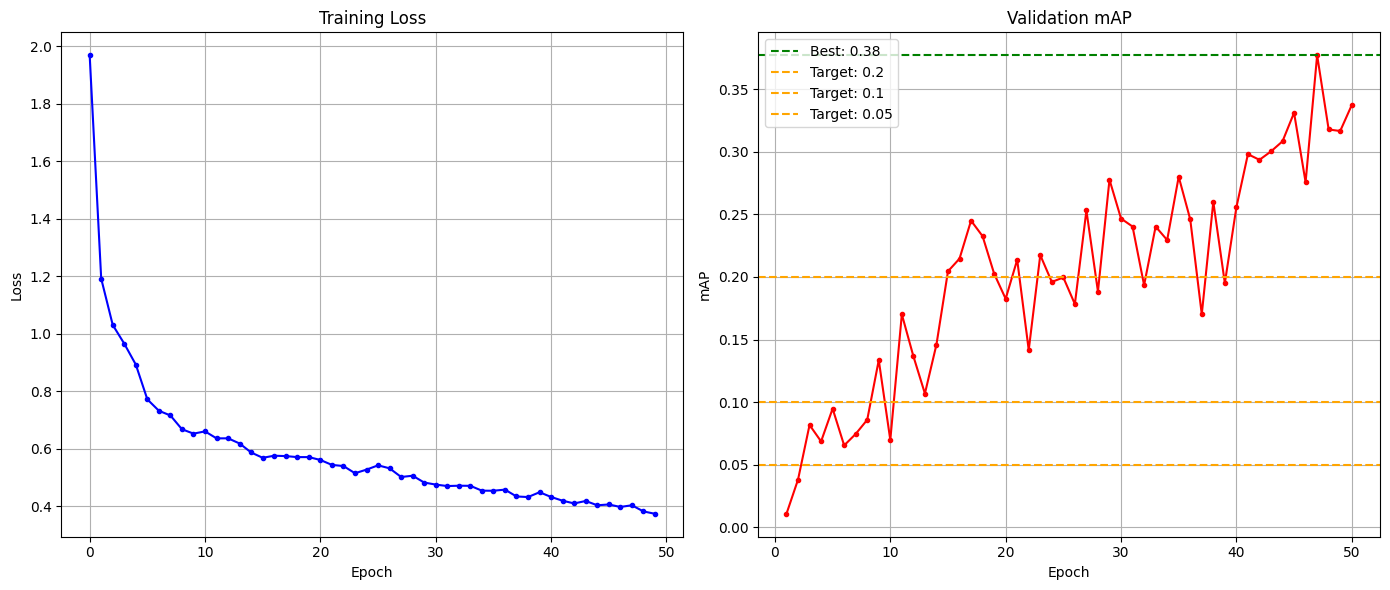

In [25]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
val_epochs = range(1, num_epochs + 1)
plt.plot(val_epochs, val_maps, 'r-o', markersize=3)
plt.axhline(y=best_map, color='g', linestyle='--', label=f'Best: {best_map:.2f}')
plt.axhline(y=0.2, color='orange', linestyle='--', label='Target: 0.2')
plt.axhline(y=0.1, color='orange', linestyle='--', label='Target: 0.1')
plt.axhline(y=0.05, color='orange', linestyle='--', label='Target: 0.05')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.title('Validation mAP')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show();

**Questions:**
1. Какой метод label assignment'a помогает лучше обучаться модели? Почему?
2. Какое из сделаных вами улучшений внесло наибольший вклад в качество модели? Как вы думаете, почему это произошло?
3. Какое из сделанных вами улучшений вообще не изменило метрику? Как вы думаете, почему это произошло?

**Answers:**
1. Лучше всего себя показывает TAL_assigner (с warmup). В отличии от других методов TAL адаптируется к текущему состоянию модели в процессе обучения, а warmup стабилизирует обучение на начальных эпохах.
2. Наибольший вклад внес переход от простой одноуровневой архитектуры к многоуровневой Neck-FPN с Разделенной головой (Decoupled Head) и CSP блоками. Это позволило детектировать объекты на разных масштабах признаков, одновременно концентрироваться на задачах классификации и определения местоположения объектов.
3. Не изменило (и даже ухудшило) метрику пробы применения сильных аугментаций.